In [1]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve
import nifty8.re as jft

from jax.lax import slice as jax_slice
from jax.scipy.signal import convolve as jax_convolve

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type, correlated_field_model, optimize_kl

jax.config.update("jax_enable_x64", True)

key = jax.random.PRNGKey(123)

Could not import MPI
/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class SignalGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, space, center=(0,0), factor=1, distances=(1.,1.)):
        check_type(space, tuple, int)
        check_type(factor, int)
        check_type(center, tuple, int)
        check_type(distances, tuple, float)

        self.space = space
        self.center = center
        self.factor = factor
        self.shape = tuple(d*self.factor for d in self.space)
        self.distances = distances

    def __repr__(self):
        return f'SignalGrid(space={self.space}, center={self.center}, factor={self.factor}, distances={self.distances})'
    
    def __mul__(self, other):
        return self.multiply_space(other)
    
    def __rmul__(self, other):
        return self.__mul__(other)

    @property
    def dom(self):
        return np.array(self.space)

    @property
    def cen(self):
        return np.array(self.center)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()
    
    @property
    def dis(self):
        return np.array(self.distances) / self.factor
    
    @property
    def coos(self):
        coos = np.indices(self.shp).astype(float)
        coos_T = coos.T.reshape(-1, 2)
        coos_T -= 0.5 * (self.shp - 1)
        coos_T /= self.factor
        coos_T += self.cen
        return coos_T.reshape(coos.T.shape).T

    @property
    def llp(self):
        return self.cen - 0.5 * (self.shp - 1) / self.factor

    @property
    def urp(self):
        return self.cen + 0.5 * (self.shp - 1) / self.factor

    def update(self, space=None, center=None, factor=None, distances=None):
        space = self.space if space is None else space
        center = self.center if center is None else center
        factor = self.factor if factor is None else factor
        distances = self.distances if distances is None else distances
        return SignalGrid(space, center, factor, distances)
    
    def multiply_space(self, factor):
        return SignalGrid.update(self, space=tuple(int(si * factor) for si in self.space))



def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def map_array(in_array, in_grid, out_grid):
    factor = 1
    if out_grid.factor < in_grid.factor:
        in_array = downsample(in_array, in_grid.factor // out_grid.factor)
        in_grid = in_grid.update(factor=out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    if in_grid.center != out_grid.center or in_grid.space != out_grid.space:
        out_array = jnp.zeros(out_grid.shape)

        llp_dif = (out_grid.llp - in_grid.llp).astype('int64')
        urp_dif = (out_grid.urp - in_grid.urp).astype('int64')

        in_min = np.maximum(llp_dif * in_grid.factor, 0)
        in_max = np.minimum(urp_dif * in_grid.factor + in_grid.shp, in_grid.shp)
        in_slc = tuple(slice(in_min[i], in_max[i]) for i in range(2))

        out_min = np.maximum(- llp_dif * out_grid.factor, 0)
        out_max = np.minimum(out_grid.shp - urp_dif * out_grid.factor, out_grid.shp)
        out_slc = tuple(slice(out_min[i], out_max[i]) for i in range(2))
        
        out_array = out_array.at[out_slc].set(in_array[in_slc])
    else:
        out_array = in_array.copy()

    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array

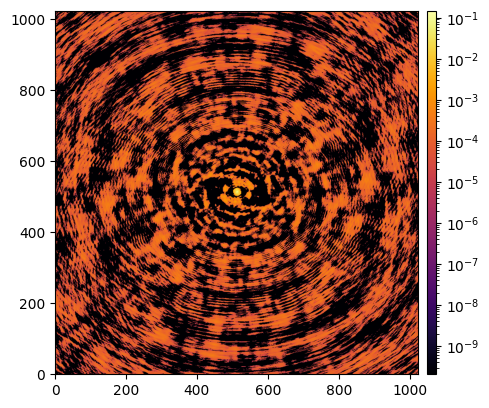

In [3]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val



obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()

space = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space)
kernel = compute_psf_kernel(RNR_l)

plot_arrays(kernel, norm='log', dpi=100)

In [4]:
class SignalModel(jft.Model):

    def __init__(self, grid, i0, prefix='sm'):
        self.grid = grid
        self.i0 = i0
        self.prefix = prefix
        super().__init__(domain=self.i0.domain, init=self.i0.init)

    def __call__(self, x, *, out_grid=None):
        res = jnp.exp(self.i0(x))
        if out_grid:
            return map_array(res, self.grid, out_grid)
        return res

In [ ]:
def jax_fft(grid):
    check_type(grid, SignalGrid)
    dvol = grid.dis.prod()
    return lambda x: dvol * jnp.fft.fftn(x)


def jax_ifft(grid):
    check_type(grid, SignalGrid)
    dvol = 1. / (grid.shp * grid.dis).prod()
    npix = grid.size
    return lambda x: dvol * npix * jnp.fft.ifftn(x)


def jax_fft_convolve(fft_kernel, grid):
    grid_l = grid.update(space=tuple(s*2 for s in grid.space))
    fft_l = jax_fft(grid_l)
    ifft_l = jax_ifft(grid_l)
    padding = grid.shp // 2

    def jax_fft_conv(array):
        p_array = jnp.pad(array, (2*(padding[0],), 2*(padding[1],)))
        c_array = ifft_l(fft_kernel * fft_l(p_array)).real
        s_array = jax_slice(c_array, padding, padding + grid.shp)
        return s_array

    return jax_fft_conv


def shift_kernel(kernel):
    s_kernel = jnp.roll(kernel, -kernel.shape[0]//2, axis=0)
    s_kernel = jnp.roll(s_kernel, -kernel.shape[1]//2, axis=1)
    return s_kernel


def build_fft_kernel(kernel, grid):
    check_type(grid, SignalGrid)
    grid_l = grid.update(space=tuple(s*2 for s in grid.space))
    s_kernel = shift_kernel(kernel)
    f_kernel = jax_fft(grid_l)(s_kernel)
    return f_kernel

In [5]:
class HighResResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.kernel = kernel
        self.dvol = model.grid.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        sig = self.model(x)
        rsp = jax_convolve(sig, self.kernel, mode='same', method='fft') * self.dvol
        return rsp



class LowResResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.factor = model.grid.factor 
        self.kernel = downsample(kernel, self.factor)
        self.dvol = self.model.grid.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        sig = self.model(x)
        fsig = downsample(sig, self.factor)
        frsp = jax_convolve(fsig, self.kernel, mode='same', method='fft') * self.dvol * (self.factor**2)
        rsp = upsample(frsp, self.factor)
        return rsp



def split_kernel(kernel, factors):
    ksize = kernel.shape[0]
    fsize = ksize // max(factors)

    skernel = np.zeros((len(factors), fsize, fsize))
    for i,f in enumerate(factors):
        ker = np.zeros_like(kernel)
        if i == 0:
            slc_in = slice(0, 0)
            slc_out = slice(ksize//2 - fsize//2, ksize//2 + fsize//2)
        else:
            slc_in = slc_out
            slc_out = slice(ksize//2 - f*fsize//2, ksize//2 + f*fsize//2)
        ker[slc_out, slc_out] = kernel[slc_out, slc_out]
        ker[slc_in, slc_in] = 0
        skernel[i] = downsample(ker[slc_out, slc_out], f)

    return skernel



class MultiKernelResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.factors = np.array([f for f in [1,2,4,8] if f <= model.grid.factor])
        print('factors:', self.factors)
        self.kernels = split_kernel(kernel, self.factors)
        print('kernels shape:', self.kernels.shape)
        self.dvol = model.grid.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        sig = self.model(x)
        rsp = jnp.zeros_like(sig)
        for i,f in enumerate(self.factors):
            fsig = downsample(sig, f)
            frsp = jax_convolve(fsig, self.kernels[i], mode='same', method='fft') * self.dvol * (f**2)
            rsp += upsample(frsp, f)
        return rsp

SignalGrid(space=(128, 128), center=(0, 0), factor=4, distances=(0.000272707695624114, 0.000272707695624114))
factors: [1 2 4]
kernels shape: (3, 256, 256)


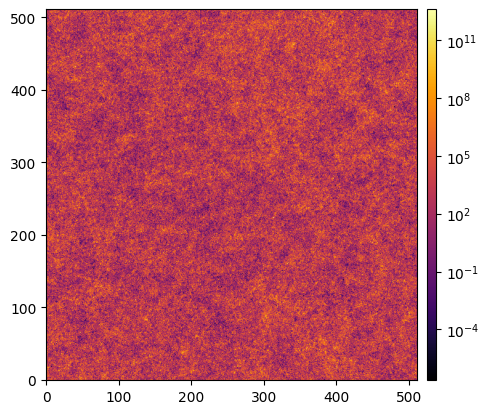

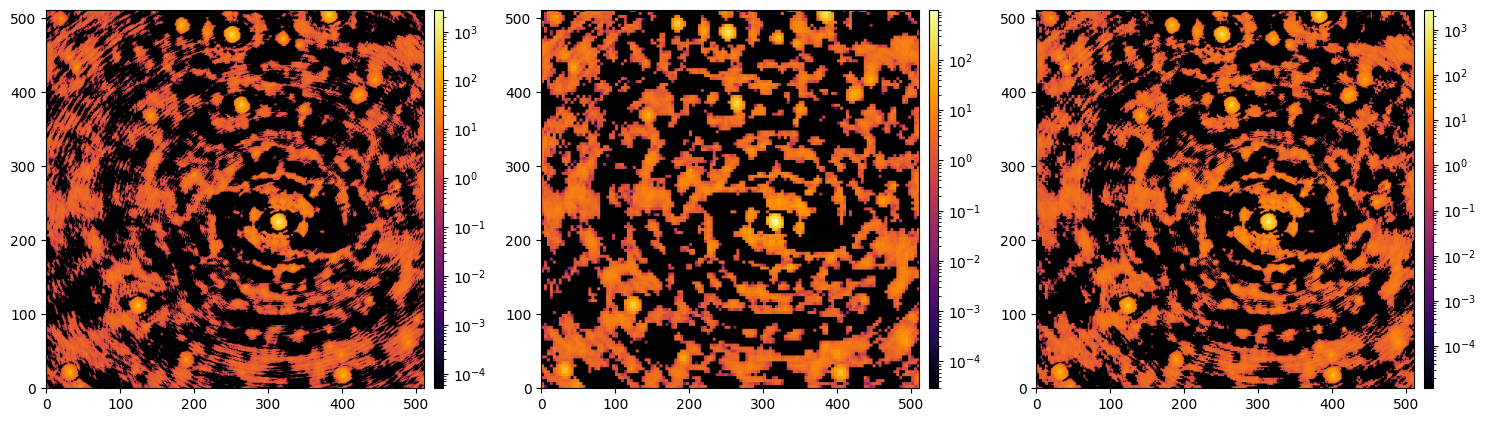

In [6]:
shape = (512, 512)
fmax = 4

space = SignalSpace.build(shape=tuple(s//fmax for s in shape), fov=('2deg', '2deg'))

grid = SignalGrid(space=tuple(s//fmax for s in shape), center=(0,0), factor=fmax, distances=space.distances)
print(grid)

bg, pw = correlated_field_model(
    prefix='bg ',
    shape=grid.shape,
    distances=grid.distances,
    offset_mean=12,
    offset_std=(1,1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
    flexibility=(1.2,0.4),
    asperity=(0.2,0.2),
)
signal = SignalModel(grid, bg, prefix='bg')


hr_response = HighResResponse(signal, kernel)

lr_response = LowResResponse(signal, kernel)

mk_response = MultiKernelResponse(signal, kernel)


key, subkey = jax.random.split(key)
prior_xi = signal.init(subkey)

plot_arrays(signal(prior_xi), rows=1, norm='log')

plot_arrays([hr_response(prior_xi), lr_response(prior_xi), mk_response(prior_xi)], rows=1, norm='log')

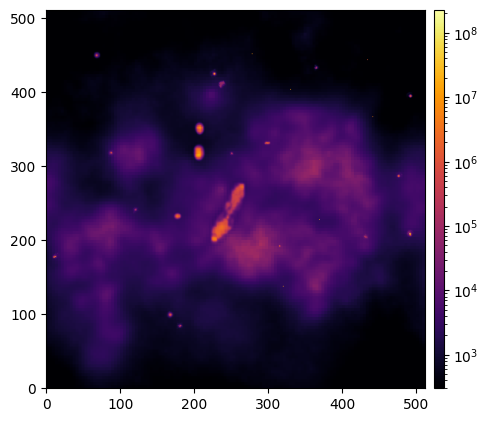

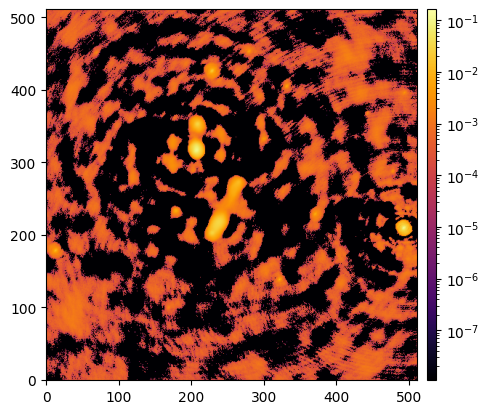

In [7]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')


sky_bg = optim_cfg.instantiate_sec('sky_bg.3')
sky_o0 = optim_cfg.instantiate_sec('sky_o0.3')
sky_o1 = optim_cfg.instantiate_sec('sky_o1.3')
sky_o2 = optim_cfg.instantiate_sec('sky_o2.3')
sky_t0 = optim_cfg.instantiate_sec('sky_t0.3')
sky_p0 = optim_cfg.instantiate_sec('sky_p0.3')



with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    samples, *_ = pickle.load(f)

rec_bg = upsample(downsample(samples.mean(sky_bg), fmax), fmax)
rec_o0 = map_signal(samples.mean(sky_o0), sky_o0.space, sky_bg.space)
rec_o1 = map_signal(samples.mean(sky_o1), sky_o1.space, sky_bg.space)
rec_o2 = map_signal(samples.mean(sky_o2), sky_o2.space, sky_bg.space)
rec_t0 = samples.mean(sky_t0)
rec_p0 = samples.mean(sky_p0)

rec = rec_bg + rec_o0 + rec_o1 + rec_o2 + rec_t0 + rec_p0
# rec = downsample(rec, 2)


def generate_data(rec, kernel, grid, n_std=1e-4):
    truth = jax_convolve(rec, kernel, mode='same', method='fft') * grid.dis.prod()
    noise = n_std * jax.random.normal(key, truth.shape)
    data = truth + noise
    return data


data = generate_data(rec, kernel, grid)


plot_arrays(rec, norm='log', vmin=3e2, vmax=rec.max(), dpi=100)
plot_arrays(data, rows=1, norm='log')


OPTIMIZE_KL: Starting 0001


s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+6.1477e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     4.7±     0.0, avg:    +0.35±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 4.8e-05±     0.0, avg:  +0.0069±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:  0.0014±     0.0, avg:   +0.038±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     1.1±     0.0, avg:     +1.0±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:    0.02±     0.0, avg:    +0.14±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00011±     0.0, avg: -0.00093±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00018±     0.0, avg:   -2e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.96±     0.0, avg:    +0.98±     0.0, #dof:      1'




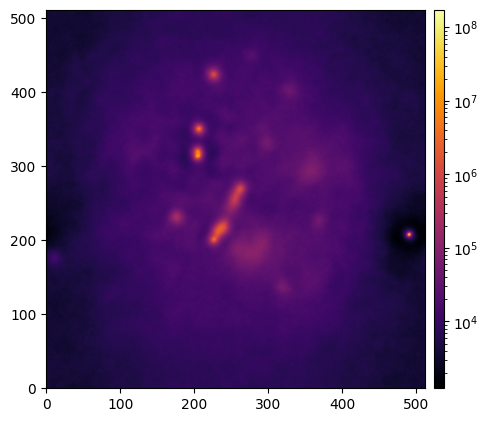

OPTIMIZE_KL: Starting 0002
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0002 ⛰:+2.4244e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.8±     0.0, avg:    +0.14±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00013±     0.0, avg:   +0.011±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:  0.0044±     0.0, avg:   +0.066±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     2.6±     0.0, avg:     +1.6±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:    0.04±     0.0, avg:     +0.2±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00011±     0.0, avg:  -0.0011±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00021±     0.0, avg: -4.1e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.3±     0.0, avg:     +1.2±     0.0, #dof:      1'




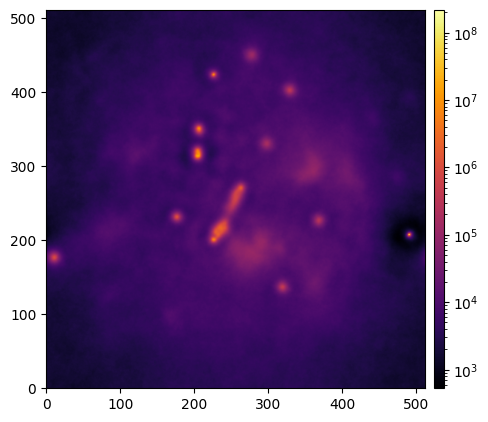

OPTIMIZE_KL: Starting 0003
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0003 ⛰:+1.8381e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.4±     0.0, avg:   +0.064±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00018±     0.0, avg:   +0.013±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:  0.0054±     0.0, avg:   +0.074±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     3.9±     0.0, avg:     +2.0±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.065±     0.0, avg:    +0.25±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00011±     0.0, avg:  -0.0012±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00023±     0.0, avg: -4.9e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.5±     0.0, avg:     +1.2±     0.0, #dof:      1'




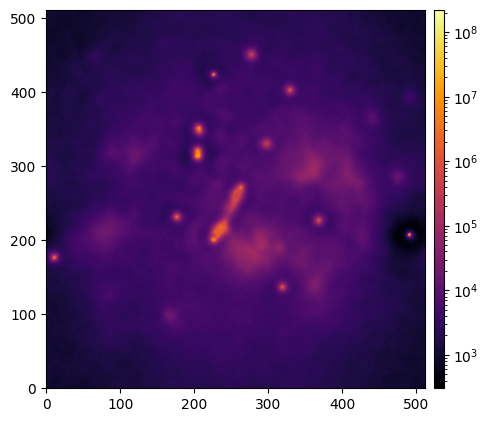

OPTIMIZE_KL: Starting 0004
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0004 ⛰:+1.5228e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.2±     0.0, avg:   +0.043±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00016±     0.0, avg:   +0.012±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:   0.005±     0.0, avg:   +0.071±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     5.4±     0.0, avg:     +2.3±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:    0.13±     0.0, avg:    +0.37±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00011±     0.0, avg:  -0.0014±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00025±     0.0, avg: -5.4e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.7±     0.0, avg:     +1.3±     0.0, #dof:      1'




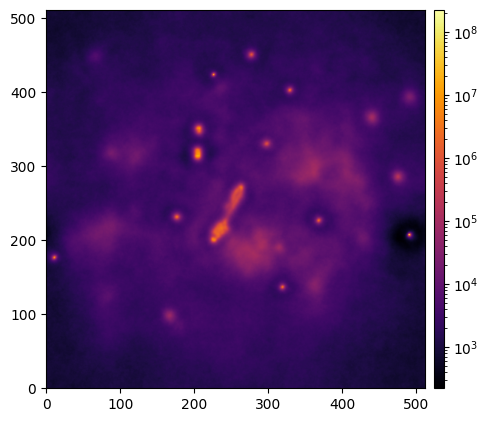

OPTIMIZE_KL: Starting 0005
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0005 ⛰:+1.4070e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±     0.0, avg:   +0.026±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00012±     0.0, avg:   +0.011±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:  0.0041±     0.0, avg:   +0.064±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     6.4±     0.0, avg:     +2.5±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:    0.18±     0.0, avg:    +0.43±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00011±     0.0, avg:  -0.0014±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00026±     0.0, avg: -5.8e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.7±     0.0, avg:     +1.3±     0.0, #dof:      1'




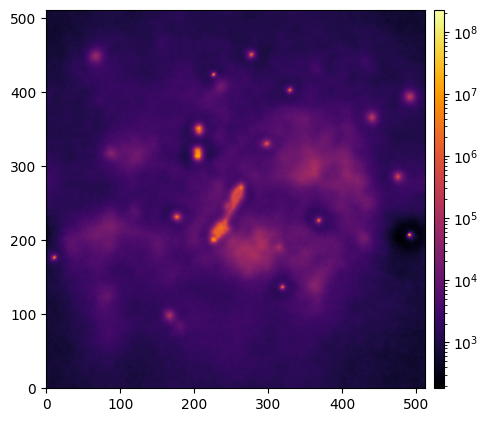

In [93]:
lh_dct = dict(
    data = data,
    model = hr_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

hr_samples, _ = optimize_kl(
    likelihood=lh_dct,
    key=45,
    n_total_iterations=5,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=10,
            maxiter=10,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+5.4255e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²: 4.1e+01±     0.0, avg:    +0.33±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00017±     0.0, avg:   +0.013±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:  0.0088±     0.0, avg:   +0.094±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:    0.99±     0.0, avg:     +1.0±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:  0.0017±     0.0, avg:   -0.042±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00012±     0.0, avg:   -0.001±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00018±     0.0, avg: -1.6e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.99±     0.0, avg:    +0.99±     0.0, #dof:      1'




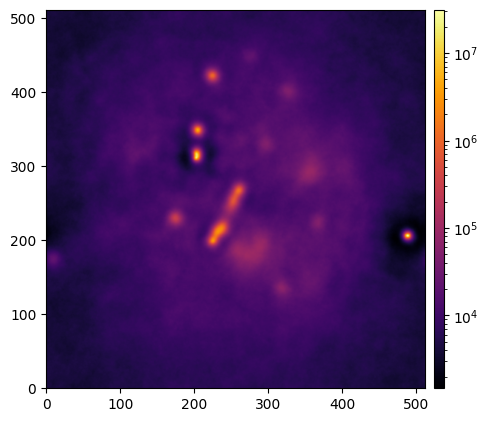

OPTIMIZE_KL: Starting 0002
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0002 ⛰:+5.1030e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²: 3.9e+01±     0.0, avg:    +0.12±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00049±     0.0, avg:   +0.022±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:   0.019±     0.0, avg:    +0.14±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     2.6±     0.0, avg:     +1.6±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:  0.0022±     0.0, avg:   -0.047±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00013±     0.0, avg:  -0.0013±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00021±     0.0, avg: -3.9e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.4±     0.0, avg:     +1.2±     0.0, #dof:      1'




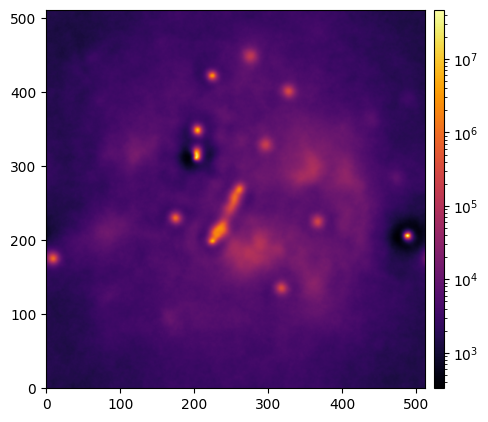

OPTIMIZE_KL: Starting 0003
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0003 ⛰:+5.0613e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²: 3.9e+01±     0.0, avg:    +0.11±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00078±     0.0, avg:   +0.028±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:   0.026±     0.0, avg:    +0.16±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     3.6±     0.0, avg:     +1.9±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²: 0.00072±     0.0, avg:   +0.027±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00013±     0.0, avg:  -0.0015±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00023±     0.0, avg: -4.6e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.4±     0.0, avg:     +1.2±     0.0, #dof:      1'




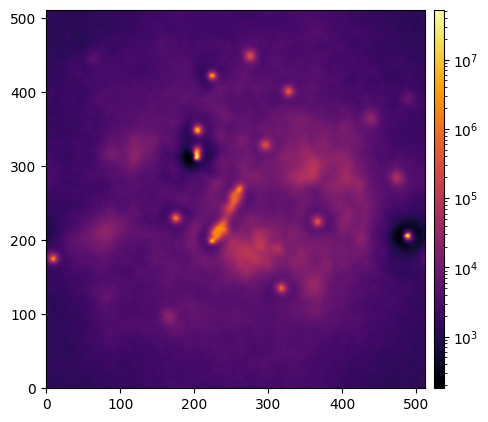

OPTIMIZE_KL: Starting 0004
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0004 ⛰:+5.0476e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²: 3.9e+01±     0.0, avg:   +0.096±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²:   0.001±     0.0, avg:   +0.032±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:   0.031±     0.0, avg:    +0.17±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     4.3±     0.0, avg:     +2.1±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:  0.0032±     0.0, avg:   +0.057±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00013±     0.0, avg:  -0.0016±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00023±     0.0, avg: -5.3e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.5±     0.0, avg:     +1.2±     0.0, #dof:      1'




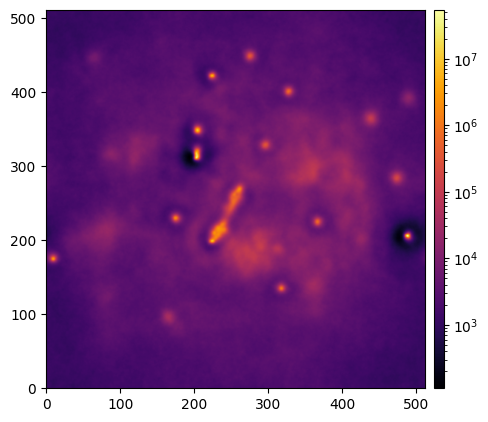

OPTIMIZE_KL: Starting 0005
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0005 ⛰:+5.0399e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²: 3.8e+01±     0.0, avg:     +0.1±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²:  0.0012±     0.0, avg:   +0.034±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:   0.034±     0.0, avg:    +0.18±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     4.7±     0.0, avg:     +2.2±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:  0.0076±     0.0, avg:   +0.087±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00013±     0.0, avg:  -0.0017±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00024±     0.0, avg: -5.7e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.5±     0.0, avg:     +1.2±     0.0, #dof:      1'




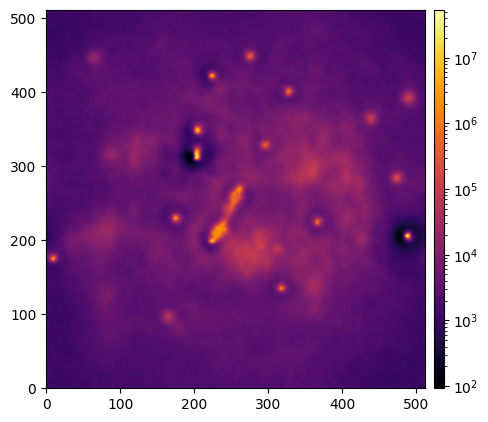

In [94]:
lh_dct = dict(
    data = data,
    model = lr_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

lr_samples, _ = optimize_kl(
    likelihood=lh_dct,
    key=45,
    n_total_iterations=5,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=10,
            maxiter=10,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+7.1000e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     5.4±     0.0, avg:    +0.36±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 5.1e-05±     0.0, avg:  +0.0071±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:  0.0017±     0.0, avg:   +0.041±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     1.1±     0.0, avg:     +1.0±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.017±     0.0, avg:    +0.13±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00011±     0.0, avg: -0.00095±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00018±     0.0, avg: -1.8e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:    0.95±     0.0, avg:    +0.98±     0.0, #dof:      1'




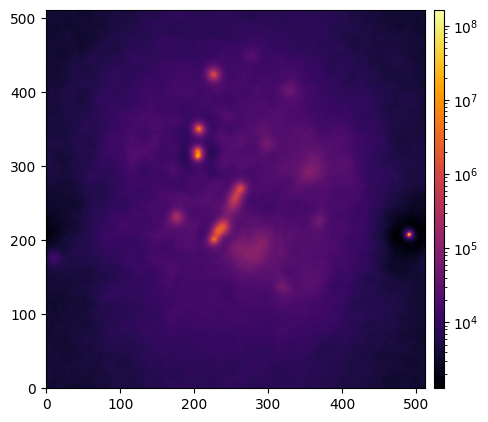

OPTIMIZE_KL: Starting 0002
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0002 ⛰:+3.3514e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     2.6±     0.0, avg:    +0.13±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00015±     0.0, avg:   +0.012±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:   0.005±     0.0, avg:   +0.071±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     2.6±     0.0, avg:     +1.6±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.038±     0.0, avg:     +0.2±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00011±     0.0, avg:  -0.0011±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00021±     0.0, avg:   -4e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.3±     0.0, avg:     +1.2±     0.0, #dof:      1'




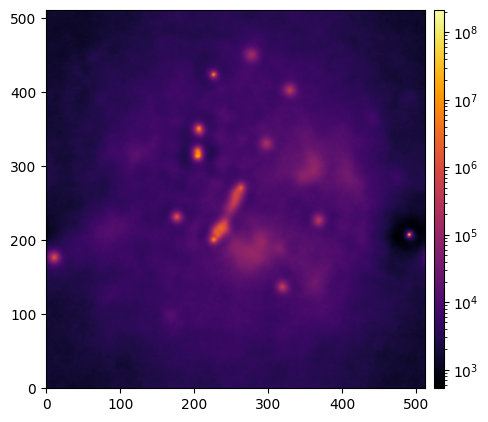

OPTIMIZE_KL: Starting 0003
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0003 ⛰:+2.7753e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     2.1±     0.0, avg:   +0.073±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00021±     0.0, avg:   +0.014±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:  0.0069±     0.0, avg:   +0.083±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     4.0±     0.0, avg:     +2.0±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.076±     0.0, avg:    +0.28±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00012±     0.0, avg:  -0.0013±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00023±     0.0, avg: -4.8e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.5±     0.0, avg:     +1.2±     0.0, #dof:      1'




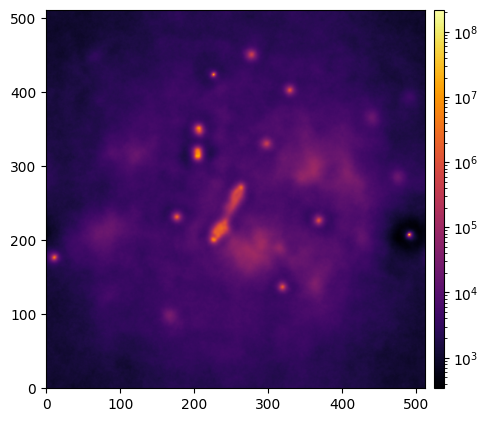

OPTIMIZE_KL: Starting 0004
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0004 ⛰:+2.5769e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     2.0±     0.0, avg:   +0.069±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²:  0.0002±     0.0, avg:   +0.014±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:   0.007±     0.0, avg:   +0.084±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     4.8±     0.0, avg:     +2.2±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:    0.12±     0.0, avg:    +0.35±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00012±     0.0, avg:  -0.0014±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00024±     0.0, avg:   -5e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.5±     0.0, avg:     +1.2±     0.0, #dof:      1'




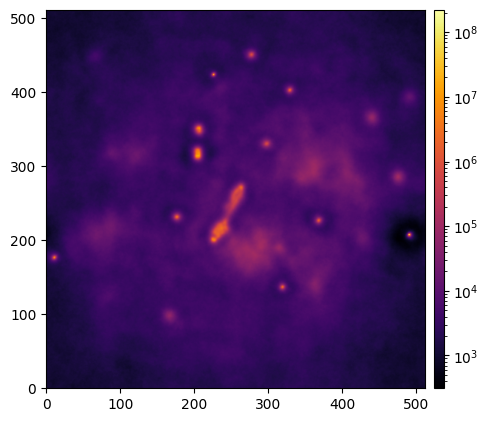

OPTIMIZE_KL: Starting 0005
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0005 ⛰:+2.4020e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.8±     0.0, avg:   +0.051±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg asperity             :: 'reduced χ²: 0.00017±     0.0, avg:   +0.013±     0.0, #dof:      1'
bg flexibility          :: 'reduced χ²:  0.0061±     0.0, avg:   +0.078±     0.0, #dof:      1'
bg fluctuations         :: 'reduced χ²:     6.1±     0.0, avg:     +2.5±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:    0.19±     0.0, avg:    +0.44±     0.0, #dof:      1'
bg spectrum             :: 'reduced χ²: 0.00012±     0.0, avg:  -0.0015±     0.0, #dof:  44048'
bg xi                   :: 'reduced χ²: 0.00025±     0.0, avg: -5.4e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:     1.6±     0.0, avg:     +1.3±     0.0, #dof:      1'




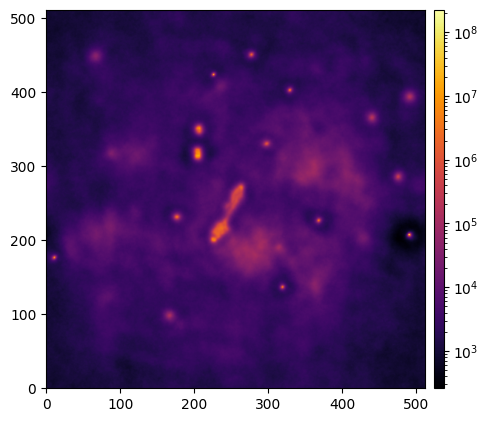

In [95]:
lh_dct = dict(
    data = data,
    model = mk_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

mk_samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=45,
    n_total_iterations=5,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=10,
            maxiter=10,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

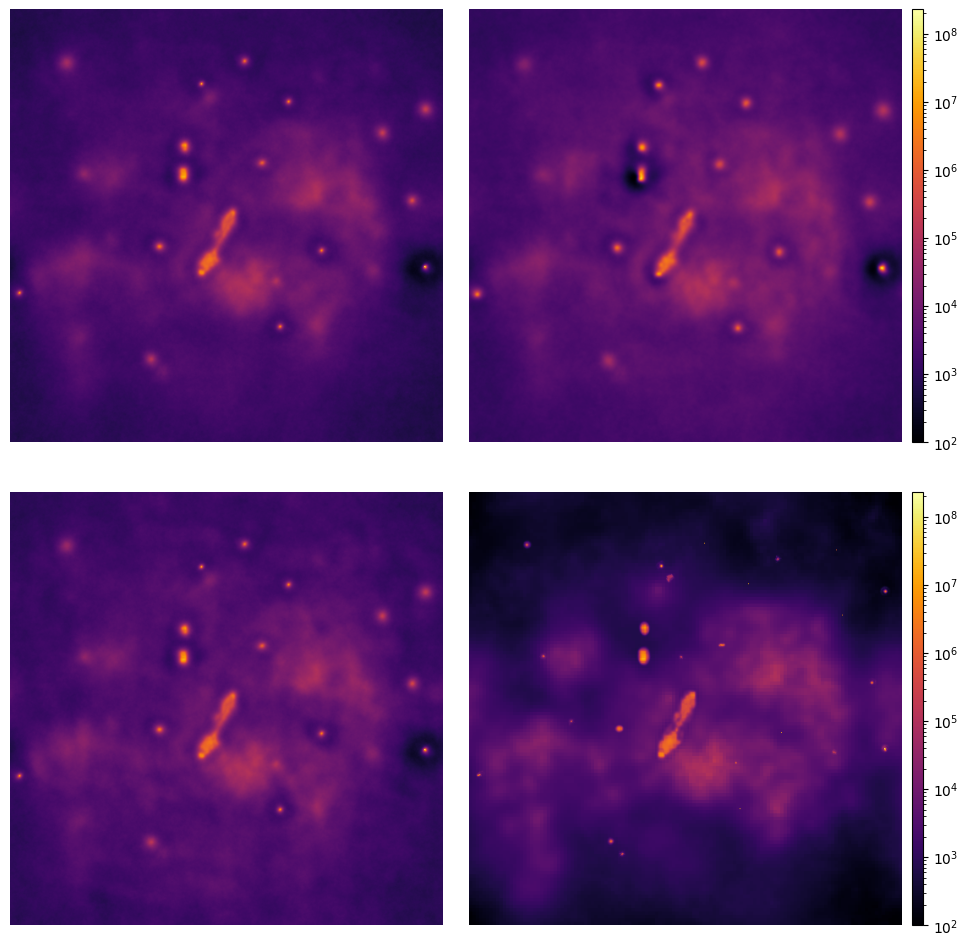

In [96]:
plot_arrays([hr_samples.mean(signal), lr_samples.mean(signal), mk_samples.mean(signal), rec], norm='log', rows=2, ticks=0, cbar=[False, True, False, True], vmin=1e2, vmax=rec.max())

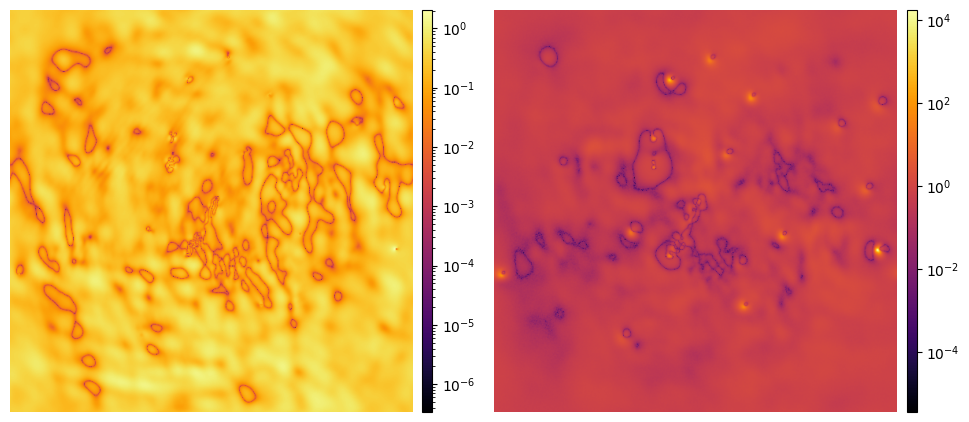

In [99]:
plot_arrays([np.abs(mk_samples.mean(signal) - hr_samples.mean(signal)) / hr_samples.mean(signal), np.abs(lr_samples.mean(signal) - hr_samples.mean(signal)) / hr_samples.mean(signal)], norm='log', rows=1, ticks=0)
